<a href="https://colab.research.google.com/github/ravichaudhary560/projects/blob/main/Loan_Approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/loan_sanction_test.csv")

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [ ]:
df[df['LoanAmount'].isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
78,LP001415,Male,Yes,1,Graduate,No,3413,4053,NaN,360.0,1.0,Semiurban
101,LP001542,Female,Yes,0,Graduate,No,2262,0,NaN,480.0,0.0,Semiurban
188,LP002057,Male,Yes,0,Not Graduate,No,13083,0,NaN,360.0,1.0,Rural
247,LP002360,Male,Yes,NaN,Graduate,No,10000,0,NaN,360.0,1.0,Urban
289,LP002593,Male,Yes,1,Graduate,No,8333,4000,NaN,360.0,1.0,Urban


In [ ]:
df.loc[78,'LoanAmount'] = 110.0
df.loc[101,'LoanAmount'] = 120.0
df.loc[188,'LoanAmount'] = 130.0
df.loc[247,'LoanAmount'] = 140.0
df.loc[289,'LoanAmount'] = 150.0


In [ ]:
df[df.Loan_Amount_Term.isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
45,LP001232,Male,Yes,0,Graduate,No,4260,3900,185.0,NaN,NaN,Urban
48,LP001268,Male,No,0,Graduate,No,6792,3338,187.0,NaN,1.0,Urban
117,LP001611,Male,Yes,1,Graduate,No,1516,2900,80.0,NaN,0.0,Rural
129,LP001695,Male,Yes,1,Not Graduate,No,3321,2088,70.0,NaN,1.0,Semiurban
184,LP002045,Male,Yes,3+,Graduate,No,10166,750,150.0,NaN,1.0,Urban
214,LP002183,Male,Yes,0,Not Graduate,No,3754,3719,118.0,NaN,1.0,Rural


In [ ]:
df.loc[45,'Loan_Amount_Term'] = 360.0
df.loc[48,'Loan_Amount_Term'] = 180.0
df.loc[117,'Loan_Amount_Term'] = 360.0
df.loc[129,'Loan_Amount_Term'] = 180.0
df.loc[184,'Loan_Amount_Term'] = 360.0
df.loc[214,'Loan_Amount_Term'] = 180.0

In [ ]:
df.Loan_Amount_Term.unique()

array([360., 240., 180.,  60., 480.,  84.,  12., 300., 350.,  36., 120.,
         6.])

In [ ]:
df[df.Gender.isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
22,LP001128,NaN,No,0,Graduate,No,3909,0,101.0,360.0,1.0,Urban
51,LP001287,NaN,Yes,3+,Not Graduate,No,3500,833,120.0,360.0,1.0,Semiurban
106,LP001563,NaN,No,0,Graduate,No,1596,1760,119.0,360.0,0.0,Urban
138,LP001769,NaN,No,NaN,Graduate,No,3333,1250,110.0,360.0,1.0,Semiurban
209,LP002165,NaN,No,1,Not Graduate,No,2038,4027,100.0,360.0,1.0,Rural
231,LP002298,NaN,No,0,Graduate,Yes,2860,2988,138.0,360.0,1.0,Urban
245,LP002355,NaN,Yes,0,Graduate,No,3186,3145,150.0,180.0,0.0,Semiurban
279,LP002553,NaN,No,0,Graduate,No,29167,0,185.0,360.0,1.0,Semiurban
296,LP002614,NaN,No,0,Graduate,No,6478,0,108.0,360.0,1.0,Semiurban
303,LP002657,NaN,Yes,1,Not Graduate,Yes,570,2125,68.0,360.0,1.0,Rural


In [ ]:
df.loc[22,'Gender'] = "Male"
df.loc[51,'Gender'] = 'Female'
df.loc[106,'Gender'] = "Male"
df.loc[138,'Gender'] = "Female"
df.loc[209,'Gender'] = "Male"
df.loc[231,'Gender'] = 'Female'
df.loc[245,'Gender'] = 'Male'
df.loc[279,'Gender'] = "Female"
df.loc[296,'Gender'] = 'Male'
df.loc[303,'Gender'] = 'Female'
df.loc[318,'Gender'] = 'Male'

In [ ]:
df[df.Dependents.isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
46,LP001237,Male,Yes,NaN,Not Graduate,No,4163,1475,162.0,360.0,1.0,Urban
70,LP001366,Female,No,NaN,Graduate,No,3250,0,95.0,360.0,1.0,Semiurban
111,LP001587,Male,Yes,NaN,Graduate,No,4082,0,93.0,360.0,1.0,Semiurban
138,LP001769,Female,No,NaN,Graduate,No,3333,1250,110.0,360.0,1.0,Semiurban
202,LP002111,Male,Yes,NaN,Graduate,No,3016,1300,100.0,360.0,NaN,Urban
247,LP002360,Male,Yes,NaN,Graduate,No,10000,0,140.0,360.0,1.0,Urban
251,LP002385,Male,Yes,NaN,Graduate,No,3863,0,70.0,300.0,1.0,Semiurban
265,LP002441,Male,No,NaN,Graduate,No,3579,3308,138.0,360.0,NaN,Semiurban
302,LP002654,Female,No,NaN,Graduate,Yes,14987,0,177.0,360.0,1.0,Rural
312,LP002754,Male,No,NaN,Graduate,No,2066,2108,104.0,84.0,1.0,Urban


In [ ]:
df.loc[46,'Dependents'] = 1
df.loc[70,'Dependents'] = 2
df.loc[111,'Dependents'] = 1
df.loc[138,'Dependents'] = 2
df.loc[202,'Dependents'] = 1
df.loc[247,'Dependents'] = 2
df.loc[251,"Dependents"] = 2
df.loc[265,'Dependents'] = 1
df.loc[302,'Dependents'] = 2
df.loc[312,'Dependents'] = 1

In [ ]:
df.Dependents.unique()

array(['0', '1', '2', '3+', 1, 2], dtype=object)

In [ ]:
df[df.Self_Employed.isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
8,LP001059,Male,Yes,2,Graduate,NaN,13633,0,280.0,240.0,1.0,Urban
11,LP001082,Male,Yes,1,Graduate,NaN,2185,1516,162.0,360.0,1.0,Semiurban
13,LP001094,Male,Yes,2,Graduate,NaN,12173,0,166.0,360.0,0.0,Semiurban
36,LP001208,Male,Yes,2,Graduate,NaN,7350,4029,185.0,180.0,1.0,Urban
72,LP001375,Male,Yes,1,Graduate,NaN,4083,1775,139.0,60.0,1.0,Urban
89,LP001472,Female,No,0,Graduate,NaN,5058,0,200.0,360.0,1.0,Rural
142,LP001789,Male,Yes,3+,Not Graduate,NaN,6794,528,139.0,360.0,0.0,Urban
161,LP001906,Male,No,0,Graduate,NaN,2964,0,84.0,360.0,0.0,Semiurban
168,LP001950,Female,Yes,3+,Graduate,NaN,1750,2935,94.0,360.0,0.0,Semiurban
175,LP001999,Male,Yes,2,Graduate,NaN,4912,4614,160.0,360.0,1.0,Rural


In [ ]:
df.Self_Employed.unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
df.loc[8,'Self_Employed'] = 'Yes'
df.loc[11,'Self_Employed'] = 'No'
df.loc[13,'Self_Employed'] = 'Yes'
df.loc[36,'Self_Employed'] = 'No'
df.loc[72,'Self_Employed'] = "Yes"
df.loc[142,'Self_Employed'] = "No"
df.loc[161,'Self_Employed'] = "Yes"
df.loc[168,'Self_Employed'] = 'No'
df.loc[175,'Self_Employed'] = 'Yes'
df.loc[192,'Self_Employed'] = 'No'
df.loc[243,'Self_Employed'] = 'Yes'
df.loc[255,'Self_Employed'] = 'No'
df.loc[276,'Self_Employed'] = "Yes"
df.loc[278,'Self_Employed'] = "No"
df.loc[285,'Self_Employed'] = 'Yes'
df.loc[287,'Self_Employed'] = 'No'
df.loc[294,'Self_Employed'] = 'Yes'
df.loc[297,'Self_Employed'] = 'Yes'
df.loc[301,'Self_Employed'] = 'No'
df.loc[323,'Self_Employed'] = 'Yes'
df.loc[326,'Self_Employed'] = 'No'

In [ ]:
df.loc[89,'Self_Employed'] = 'No'
df.loc[259,'Self_Employed'] = 'Yes'

In [ ]:
df[df.Credit_History.isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
12,LP001083,Male,No,3+,Graduate,No,4166,0,40.0,180.0,NaN,Urban
26,LP001163,Male,Yes,2,Graduate,No,4363,1250,140.0,360.0,NaN,Urban
28,LP001174,Male,Yes,0,Graduate,No,3772,833,57.0,360.0,NaN,Semiurban
45,LP001232,Male,Yes,0,Graduate,No,4260,3900,185.0,360.0,NaN,Urban
90,LP001475,Male,Yes,0,Graduate,Yes,3188,2286,130.0,360.0,NaN,Rural
99,LP001527,Male,Yes,3+,Graduate,No,6835,0,188.0,360.0,NaN,Semiurban
104,LP001558,Male,No,0,Graduate,No,2243,2233,107.0,360.0,NaN,Semiurban
115,LP001601,Male,No,3+,Graduate,No,4243,4123,157.0,360.0,NaN,Semiurban
139,LP001771,Female,No,3+,Graduate,No,4083,0,103.0,360.0,NaN,Semiurban


In [ ]:
df.loc[3,'Credit_History'] = 1.0
df.loc[12,'Credit_History'] = 0.0
df.loc[26,'Credit_History'] = 1.0
df.loc[28,'Credit_History'] = 1.0
df.loc[45,'Credit_History'] = 0.0
df.loc[90,'Credit_History'] = 1.0
df.loc[99,'Credit_History'] = 0.0
df.loc[104,'Credit_History'] = 1.0
df.loc[115,'Credit_History'] = 0.0
df.loc[139,'Credit_History'] =1.0
df.loc[143,'Credit_History'] = 0.0
df.loc[164,'Credit_History'] = 1.0
df.loc[177,'Credit_History'] = 0.0
df.loc[179,'Credit_History'] = 1.0
df.loc[185,'Credit_History'] = 0.0
df.loc[202,'Credit_History'] = 1.0
df.loc[220,'Credit_History'] = 0.0
df.loc[259,'Credit_History'] = 1.0
df.loc[262,'Credit_History'] = 0.0
df.loc[265,'Credit_History'] = 1.0
df.loc[282,'Credit_History'] = 0.0
df.loc[286,'Credit_History'] = 1.0
df.loc[305,'Credit_History'] = 0.0
df.loc[329,'Credit_History'] = 1.0
df.loc[336,'Credit_History'] = 0.0
df.loc[351,'Credit_History'] = 1.0
df.loc[358,'Credit_History'] = 0.0
df.loc[360,'Credit_History'] = 1.0
df.loc[364,'Credit_History'] = 0.0

In [ ]:
df.Credit_History.unique()

array([1., 0.])

In [ ]:
df.isnull().sum().sum()

np.int64(0)

<Axes: >

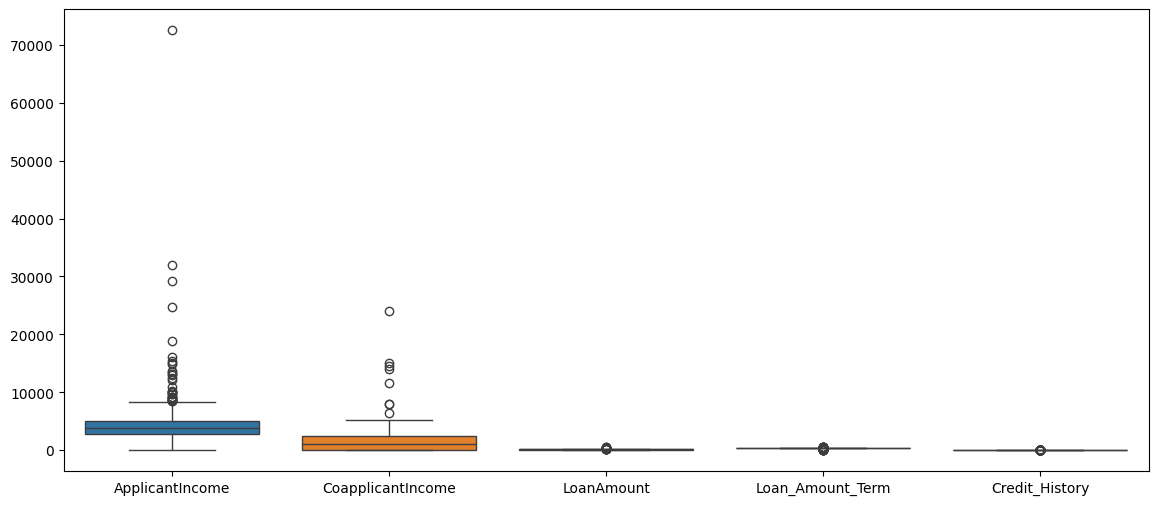

In [ ]:
 plt.figure(figsize=(14, 6))
sns.boxplot(df)

<Figure size 1.02e+06x600 with 0 Axes>

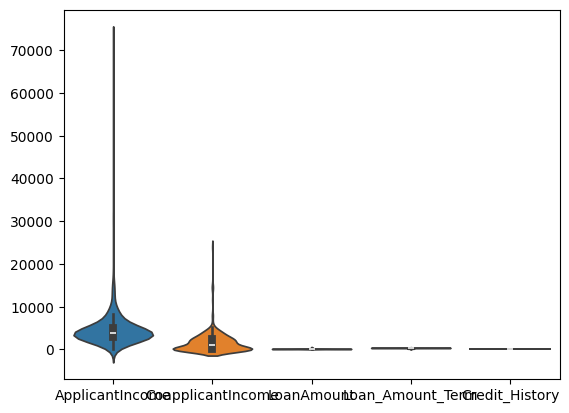

<Figure size 1.02e+06x600 with 0 Axes>

In [ ]:
sns.violinplot(df)
plt.figure(figsize=(10200,6))

<Axes: >

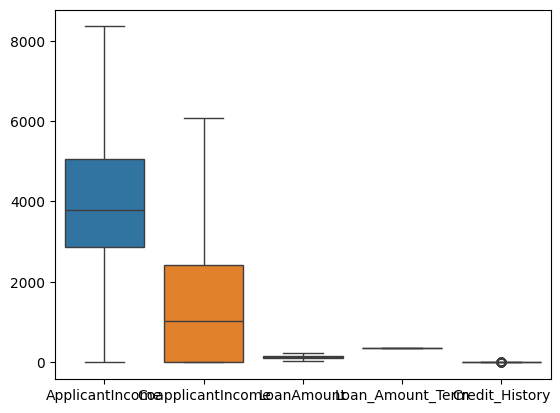

In [ ]:
sns.boxplot(df)

In [ ]:
# Identify numerical columns (excluding 'Credit_History' which is categorical)
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Calculate Q1, Q3, and IQR for each numerical column
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

print("Q1:\n", Q1)
print("\nQ3:\n", Q3)
print("\nIQR:\n", IQR)

Q1:
 ApplicantIncome      2864.0
CoapplicantIncome       0.0
LoanAmount            101.0
Loan_Amount_Term      360.0
Name: 0.25, dtype: float64

Q3:
 ApplicantIncome      5060.0
CoapplicantIncome    2430.5
LoanAmount            157.5
Loan_Amount_Term      360.0
Name: 0.75, dtype: float64

IQR:
 ApplicantIncome      2196.0
CoapplicantIncome    2430.5
LoanAmount             56.5
Loan_Amount_Term        0.0
dtype: float64


In [ ]:
# Determine outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap the outliers
for col in numerical_cols:
    df[col] = np.where(df[col] < lower_bound[col], lower_bound[col], df[col])
    df[col] = np.where(df[col] > upper_bound[col], upper_bound[col], df[col])

print("Outliers handled by capping.")

Outliers handled by capping.


In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720.0,0.0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076.0,1500.0,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000.0,1800.0,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340.0,2546.0,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276.0,0.0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009.0,1777.0,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158.0,709.0,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250.0,1993.0,126.0,360.0,0.0,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000.0,2393.0,158.0,360.0,1.0,Rural


In [ ]:
df.Education.unique()

array(['Urban', 'Semiurban', 'Rural'], dtype=object)

In [ ]:
for col in df.select_dtypes(include='object').columns:
    empty_strings_count = (df[col] == '').sum()
    if empty_strings_count > 0:
        print(f"Column '{col}' has {empty_strings_count} empty strings.")
    else:
        print(f"Column '{col}' has no empty strings.")

Column 'Loan_ID' has no empty strings.
Column 'Gender' has no empty strings.
Column 'Married' has no empty strings.
Column 'Dependents' has no empty strings.
Column 'Education' has no empty strings.
Column 'Self_Employed' has no empty strings.
Column 'Property_Area' has no empty strings.


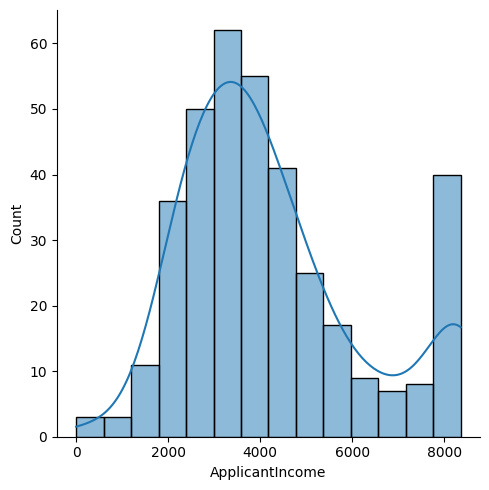

In [ ]:
sns.displot(df,x='ApplicantIncome',kde=True)

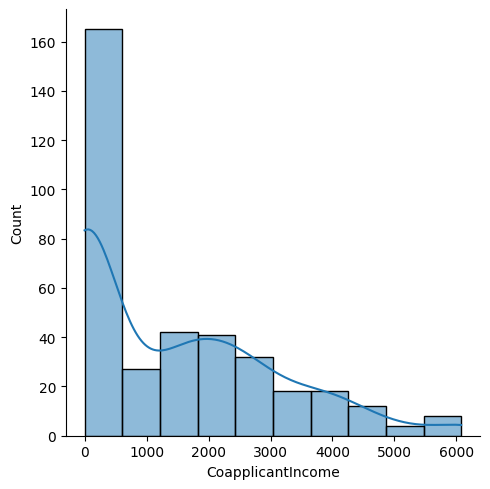

In [ ]:
sns.displot(df,x="CoapplicantIncome",kde=True)

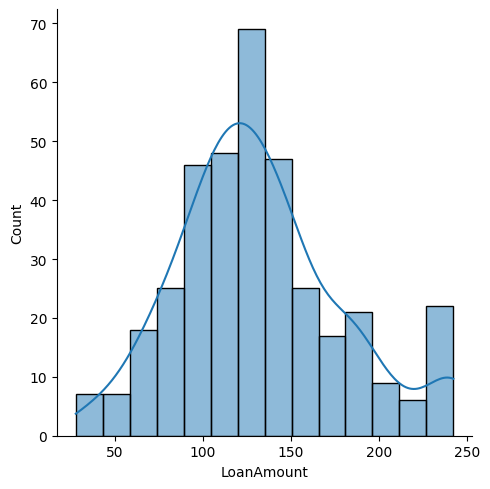

In [ ]:
sns.displot(df,x='LoanAmount',kde=True,)

<Axes: xlabel='Loan_Amount_Term', ylabel='count'>

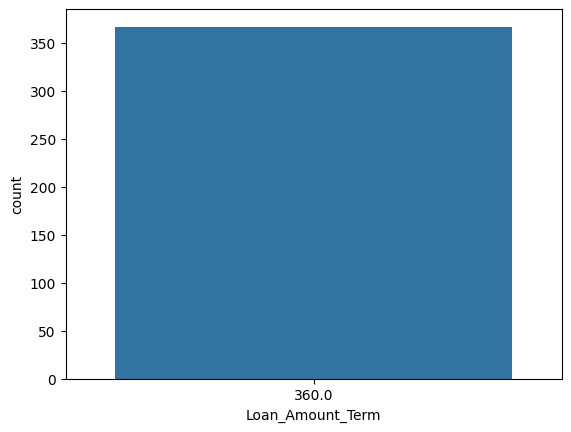

In [ ]:
sns.countplot(df,x="Loan_Amount_Term")

In [ ]:
print(f"Q1 for Loan_Amount_Term: {Q1['Loan_Amount_Term']}")
print(f"Q3 for Loan_Amount_Term: {Q3['Loan_Amount_Term']}")
print(f"IQR for Loan_Amount_Term: {IQR['Loan_Amount_Term']}")
print(f"Lower bound for Loan_Amount_Term: {lower_bound['Loan_Amount_Term']}")
print(f"Upper bound for Loan_Amount_Term: {upper_bound['Loan_Amount_Term']}")

Q1 for Loan_Amount_Term: 360.0
Q3 for Loan_Amount_Term: 360.0
IQR for Loan_Amount_Term: 0.0
Lower bound for Loan_Amount_Term: 360.0
Upper bound for Loan_Amount_Term: 360.0
